In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\saira\Downloads\telecom_churn.csv")

In [3]:
df.shape
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Data Cleaning and Missing Value Assessment

df.isnull().sum()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

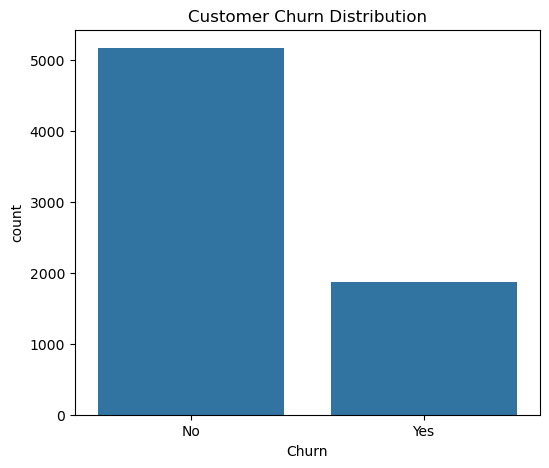

In [6]:
# Overall Customer Churn Distribution

plt.figure(figsize=(6,5))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

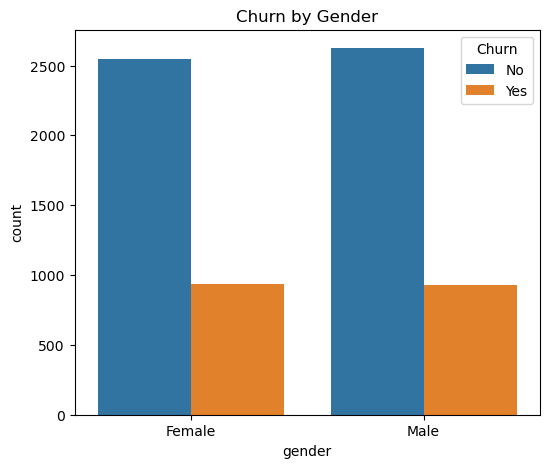

In [7]:
# Gender-wise Churn Analysis

plt.figure(figsize=(6,5))
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Churn by Gender")
plt.show()

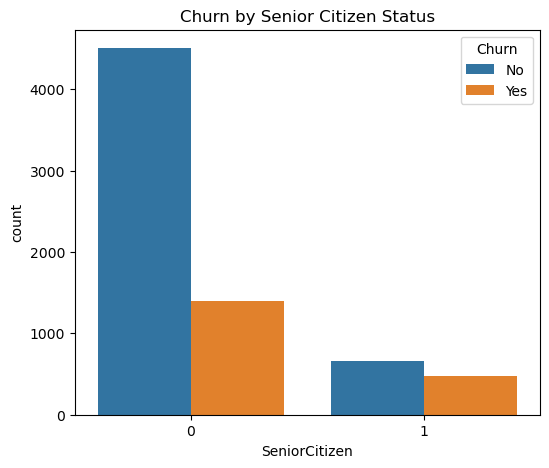

In [8]:
# Senior Citizen Churn Analysis

plt.figure(figsize=(6,5))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title("Churn by Senior Citizen Status")
plt.show()

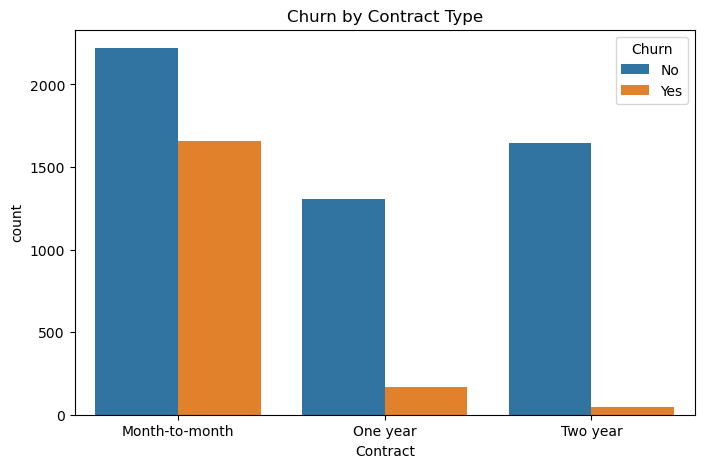

In [9]:
# Contract Type Impact on Churn

plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

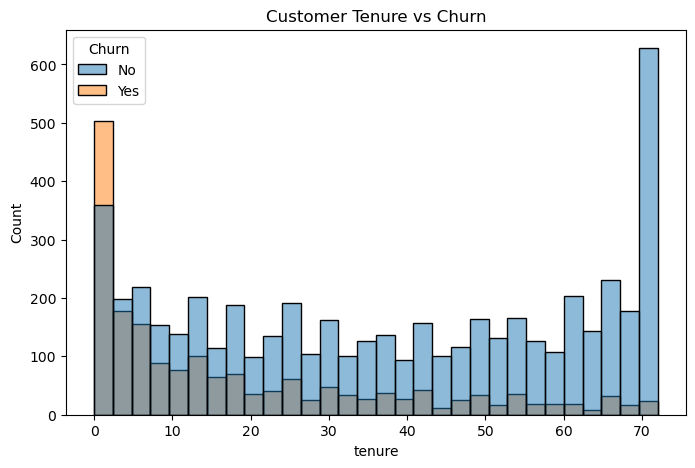

In [10]:
# Tenure vs Churn Analysis

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30)
plt.title("Customer Tenure vs Churn")
plt.show()

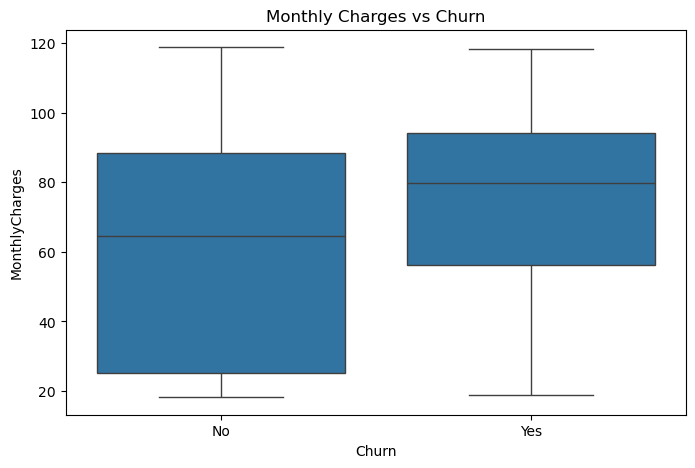

In [11]:
# Monthly Charges Impact on Churn

plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

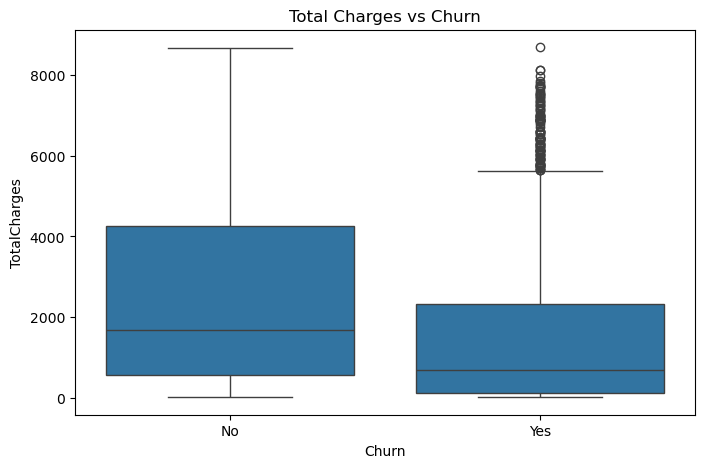

In [12]:
# Total Charges vs Churn

plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.title("Total Charges vs Churn")
plt.show()

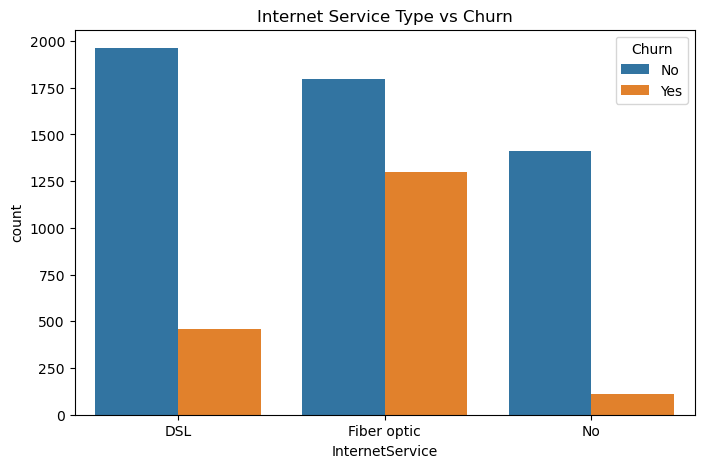

In [13]:
# Internet Service Type vs Churn

plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Internet Service Type vs Churn")
plt.show()

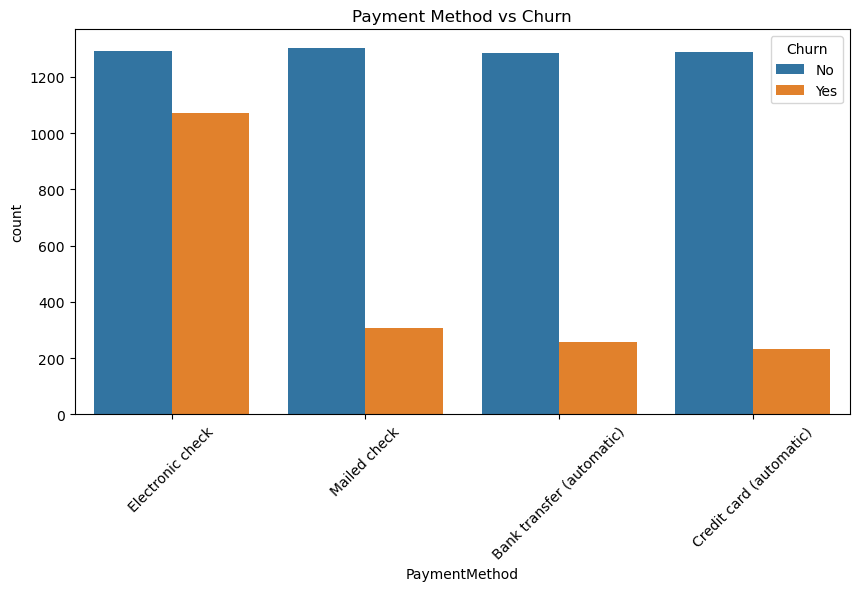

In [14]:
# Payment Method Impact on Churn

plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

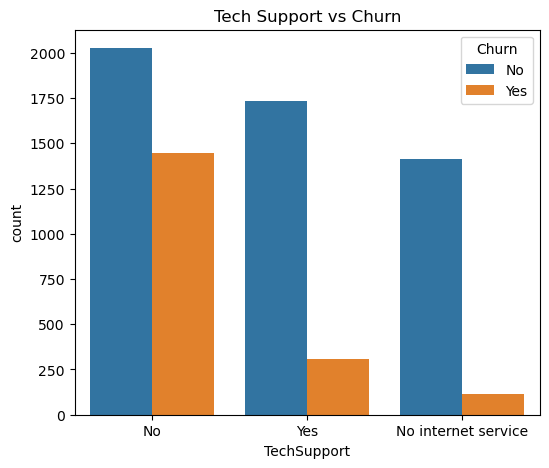

In [15]:
# Tech Support Impact on Churn

plt.figure(figsize=(6,5))
sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.title("Tech Support vs Churn")
plt.show()

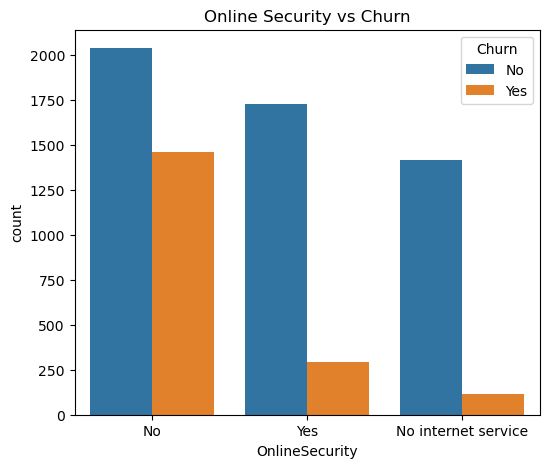

In [16]:
# Online Security Impact on Churn

plt.figure(figsize=(6,5))
sns.countplot(x='OnlineSecurity', hue='Churn', data=df)
plt.title("Online Security vs Churn")
plt.show()

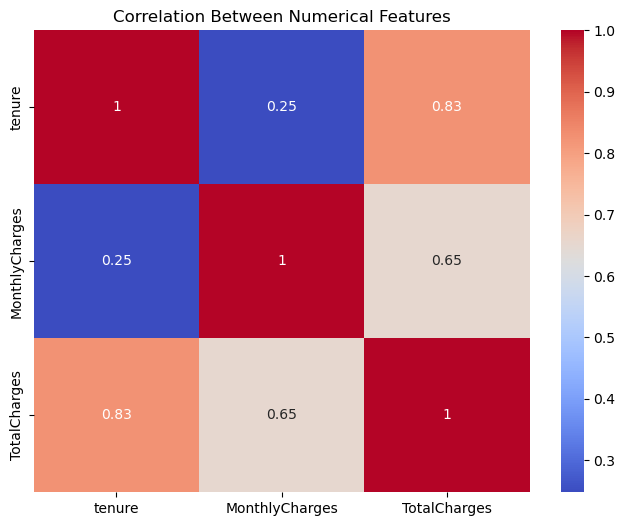

In [17]:
# Correlation Analysis of Numerical Variables

plt.figure(figsize=(8,6))
corr = df[['tenure','MonthlyCharges','TotalCharges']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Numerical Features")
plt.show()

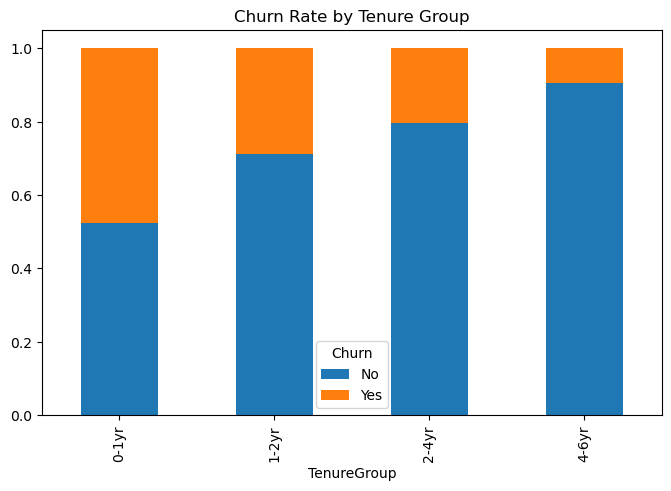

In [20]:
# Churn Rate by Tenure Group (Advanced BA Insight)

df['TenureGroup'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], labels=['0-1yr','1-2yr','2-4yr','4-6yr'])

tenure_churn = df.groupby('TenureGroup', observed=False)['Churn'].value_counts(normalize=True).unstack()

tenure_churn.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Churn Rate by Tenure Group")
plt.show()
